# PhysSet-DOA: Geometry-Aware Physics-Guided Set Prediction for Multi-Source 3D DOA Estimation

---

## 1. 연구 목표

마이크의 개수와 배치가 달라지는 환경에서 다중 음원의 3차원 도래방향(Direction of Arrival, DOA)을 추정

기존 딥러닝 기반 DOA 추정 모델은 특정 마이크 배열에 종속되거나, 고정된 방향 그리드에 대해 분류를 수행하는 경우가 많음.  
이러한 방식은 학습 시 사용하지 않은 마이크 배열에 대한 일반화가 어렵고, 방향 해상도가 미리 설정된 그리드 간격에 제한되는 한계를 가짐.

이를 해결하기 위해 PhysSet-DOA는 다음 요소를 결합.

1. 마이크 배열을 순서 없는 기하학적 집합으로 처리하는 geometry-aware encoder
2. 다중 음원을 순서 없는 방향 집합으로 출력하는 set prediction decoder
3. 각 방향을 연속적인 3차원 단위벡터로 표현하는 grid-free DOA estimation
4. 기본 모델 수렴 후 선택적으로 적용하는 physics-guided covariance decoder
5. 마이크 배열 회전, 채널 제거 및 위치 오차를 포함하는 data augmentation

---

## 2. 문제 정의

마이크의 개수를 \(M\), 시간 프레임의 수를 \(T\), 주파수 bin의 수를 \(F\)라고 정의

다채널 입력 신호의 STFT는 다음과 같이 표현

$$
\mathbf X
=
\left\{
X_m(f,t)
\right\}_{m=1}^{M}
\in
\mathbb C^{M\times F\times T}
$$

각 마이크의 3차원 좌표는 다음과 같다.

$$
\mathbf r_m
=
[x_m,y_m,z_m]^\top
\in
\mathbb R^3
$$

모델은 오디오 신호와 마이크 위치를 입력받는다.

$$
f_\theta:
(\mathbf X,\mathbf R)
\rightarrow
\hat{\mathcal S}
$$

여기서

$$
\mathbf R
=
\{\mathbf r_m\}_{m=1}^{M}
$$

이며, 출력 $\hat{\mathcal{S}}$는 순서가 없는 복수 음원의 방향 집합이다.

$$
\hat{\mathcal S}
=
\left\{
\hat{s}_k
\right\}_{k=1}^{K_{\max}}
$$

각 source slot $\hat s_k$는 다음 값을 포함한다.

$$
\hat s_k
=
\left(
\hat p_k,
\hat{\mathbf u}_k
\right)
$$

- $\hat p_k$: $k$번째 source slot이 활성 음원일 확률
- $\hat{\mathbf u}_k$: 예측된 3차원 DOA 단위벡터
- $K_{\max}$: 모델이 동시에 추정할 수 있는 최대 음원 수

실제 음원 수 $K$는 고정하지 않으며 다음을 만족한다.

$$
0\le K\le K_{\max}
$$

---

## 3. 3차원 DOA 표현

방위각과 고도를 직접 회귀하면 방위각의 $0^\circ$와 $360^\circ$ 경계에서 불연속성이 발생할 수 있다. 또한 고도각의 극점 부근에서는 동일한 방향이 서로 다른 각도 조합으로 표현되는 문제가 발생한다.

따라서 본 연구에서는 DOA를 Cartesian 단위벡터로 표현한다.

방위각을 $\phi$, 고도각을 $\theta$라고 할 때 방향벡터는 다음과 같다.

$$
\mathbf u
=
\begin{bmatrix}
\cos\theta\cos\phi\\
\cos\theta\sin\phi\\
\sin\theta
\end{bmatrix}
$$

모델은 정규화 이전의 벡터 $\mathbf v_k\in\mathbb R^3$를 출력하고 다음과 같이 단위벡터로 변환한다.

$$
\hat{\mathbf u}_k
=
\frac{\mathbf {v}_k}
{||\mathbf {v}_k||_2+\epsilon}
$$

최종 방위각과 고도각은 다음과 같이 계산한다.

$$
\hat\phi_k
=
\operatorname{atan2}
(\hat u_{k,y},\hat u_{k,x})
$$

$$
\hat\theta_k
=
\operatorname{atan2}
\left(
\hat u_{k,z},
\sqrt{
\hat u_{k,x}^2+\hat u_{k,y}^2
}
\right)
$$

---

## 4. 전체 모델 구조

PhysSet-DOA는 다음 다섯 개 모듈로 구성

```text
Multi-channel waveform
        │
        ▼
STFT and pairwise spatial feature extraction
        │
        ▼
Geometry-aware pair encoder
        │
        ▼
Microphone set / graph encoder
        │
        ▼
Multi-source query decoder
        │
        ├── Activity probability
        ├── Continuous 3D DOA vector
        └── Time-frequency source responsibility (optional physics stage)
        │
        ▼
Physics-guided spatial covariance decoder
```

---

## 5. 신호 전처리 및 공간 특징 추출

### 5.1 STFT

각 마이크 신호 $x_m[n]$에 대해 STFT를 수행한다.

$$
X_m(f,t)
=
\sum_n
x_m[n]
w[n-tH]
e^{-j2\pi fn/N}
$$

여기서 $N$은 FFT 크기, $H$는 hop size, $w[\cdot]$는 window function이다.

권장 초기 설정은 다음과 같다.

| 항목 | 설정 예시 |
|---|---:|
| Sampling rate | 16 kHz 또는 24 kHz |
| FFT size | 512 또는 1024 |
| Window length | 32 ms |
| Hop length | 8–16 ms |
| Maximum source count | 3 또는 4 |

---

n_spk=1  n_channel=12  mic_dim=D3
input_audio shape=(12, 51691)
mic_coordinate shape=(12, 3)
spherical_position shape=(1, 3, 51691)
speaker 0 DOA: azimuth=148.4 deg, elevation=92.4 deg, distance=2.60 m


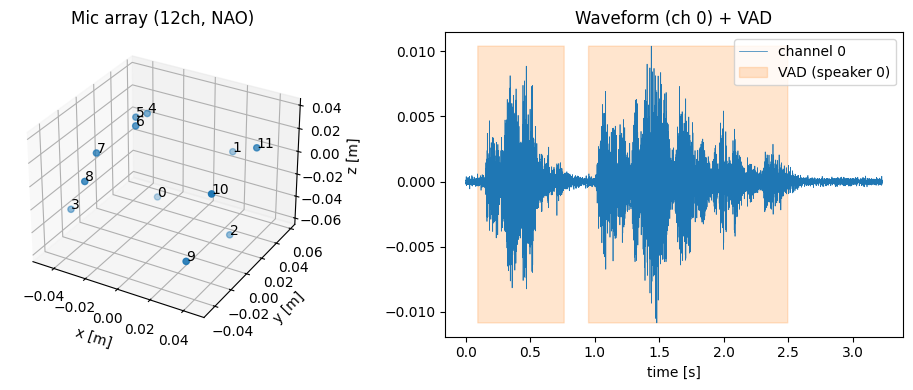

In [7]:
# 예시 데이터: LOCATA
import pickle

import numpy as np
import matplotlib.pyplot as plt

with open("datasets/locata_eval/nao/0.pkl", "rb") as f:
    df = pickle.load(f)

sample = df.iloc[0].to_dict()  # 이 파일에 저장된 recording 하나

print(f"n_spk={sample['n_spk']}  n_channel={sample['n_channel']}  mic_dim={sample['mic_dim']}")
print(f"input_audio shape={sample['input_audio'].shape}")
print(f"mic_coordinate shape={sample['mic_coordinate'].shape}")
print(f"spherical_position shape={sample['spherical_position'].shape}")

az, el, dist = sample["spherical_position"][0, :, 0]  # 정적 음원이므로 t=0 값이 전체를 대표
print(f"speaker 0 DOA: azimuth={az:.1f} deg, elevation={el:.1f} deg, distance={dist:.2f} m")

fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
mic = sample["mic_coordinate"]
ax1.scatter(mic[:, 0], mic[:, 1], mic[:, 2], c="tab:blue")
for i, (x, y, z) in enumerate(mic):
    ax1.text(x, y, z, str(i))
ax1.set_title(f"Mic array ({sample['n_channel']}ch, NAO)")
ax1.set_xlabel("x [m]"); ax1.set_ylabel("y [m]"); ax1.set_zlabel("z [m]")

ax2 = fig.add_subplot(1, 2, 2)
audio = sample["input_audio"][0]
vad = sample["vad"][0]
t = np.arange(len(audio)) / 16000
ax2.plot(t, audio, linewidth=0.5, label="channel 0")
ax2.fill_between(t, audio.min(), audio.max(), where=vad, alpha=0.2, color="tab:orange", label="VAD (speaker 0)")
ax2.set_title("Waveform (ch 0) + VAD")
ax2.set_xlabel("time [s]")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

waveform shape: (1, 12, 51691)
STFT shape: (12, 257, 201) (channel, frequency, frame)


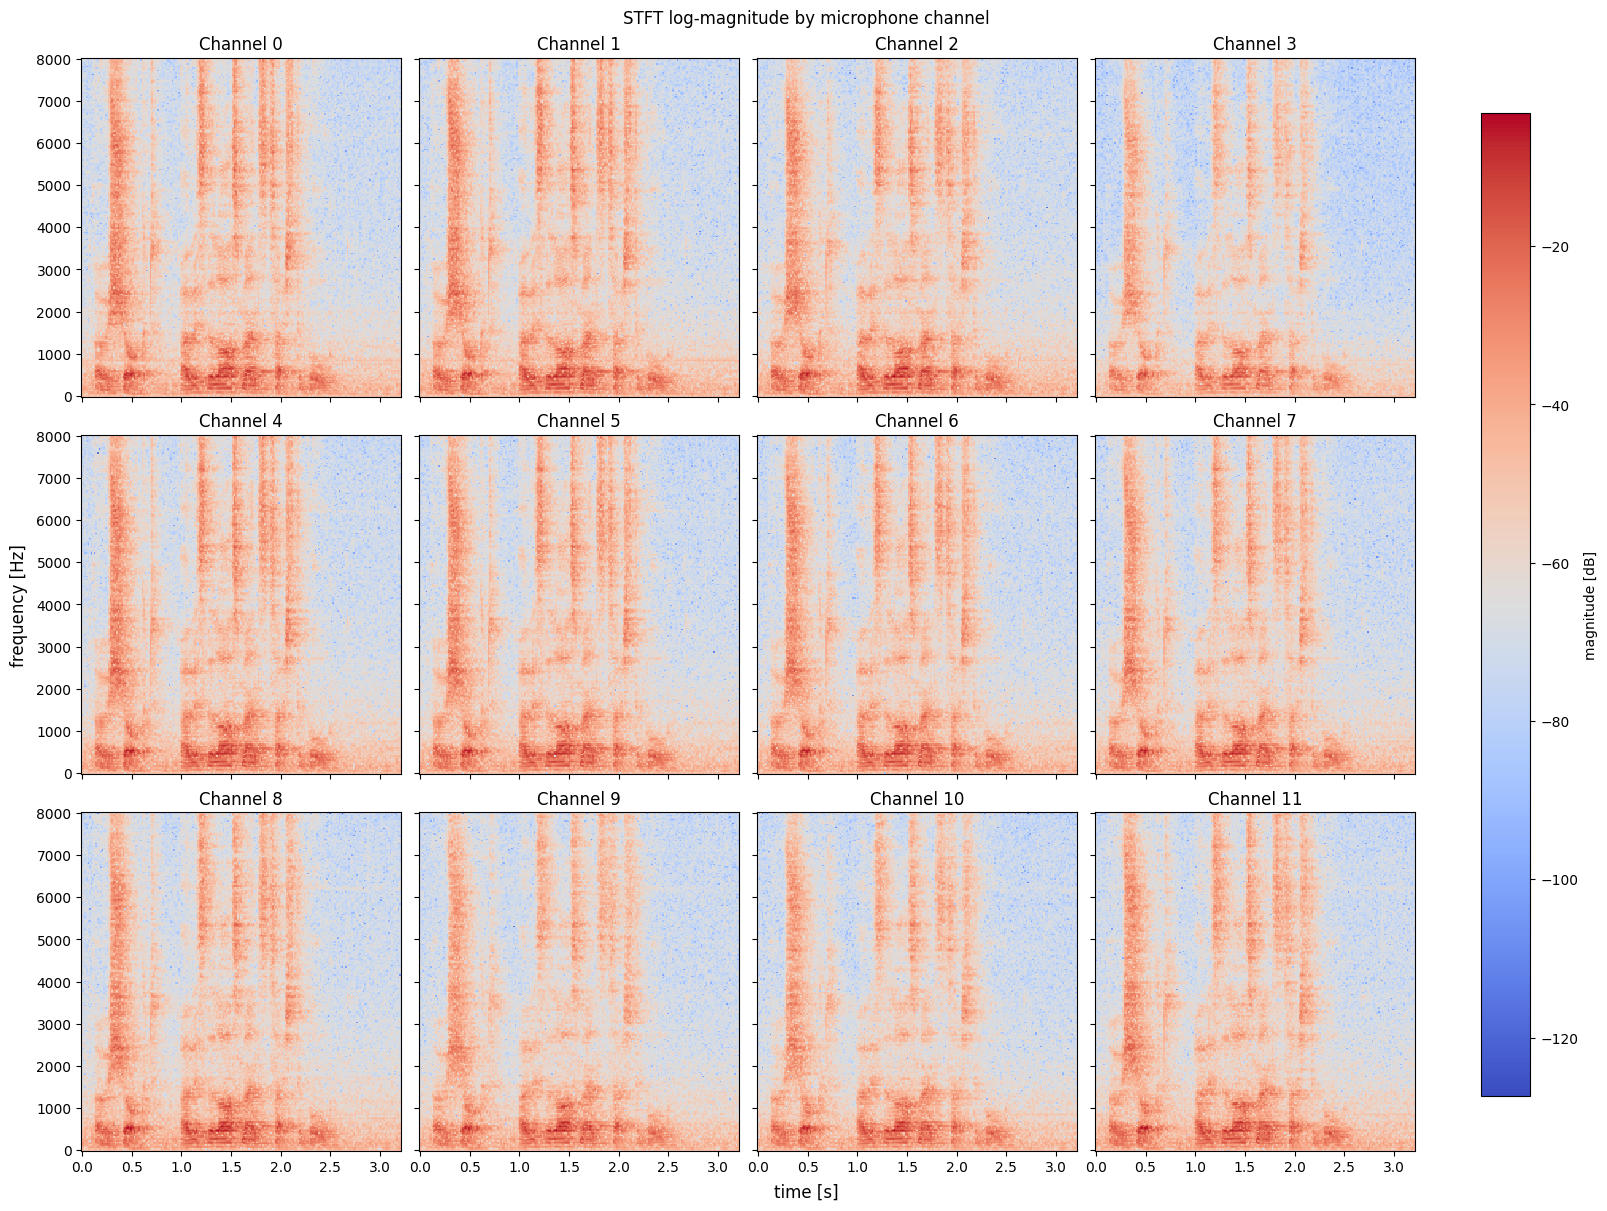

In [ ]:
import torch
from input_feature_process import Input_feature_process

# sample의 (channel, sample) 파형을 (batch, channel, sample) 텐서로 변환
waveform = torch.as_tensor(sample["input_audio"], dtype=torch.float32).unsqueeze(0)

# Input_feature_process 내부의 ConvSTFT를 사용
# 16 kHz에서 32 ms window(512 samples), 8 ms hop(128 samples), Hann window 설정
feature_processor = Input_feature_process(win_len=512).to(waveform.device)
stft = feature_processor.STFT

real, imag = stft(waveform, cplx=True)  # 각각 (B, C, F, T)
X = torch.complex(real, imag)[0]     # batch 축 제거: (C, F, T)

print(f"waveform shape: {tuple(waveform.shape)}")
print(f"STFT shape: {tuple(X.shape)} (channel, frequency, frame)")

# 마이크 채널별 log-magnitude spectrogram
magnitude_db = 20 * torch.log10(X.abs().clamp_min(1e-8))
time_axis = torch.arange(X.shape[-1]) * stft.stride / 16000
freq_axis = torch.arange(X.shape[-2]) * 16000 / stft.fft_len

magnitude_db_np = magnitude_db.detach().numpy()  # 텐서 -> numpy 배열로 변환

# 채널 간 비교가 가능하도록 모든 subplot에 같은 색상 범위(min~max)를 사용
vmin = magnitude_db_np.min()
vmax = magnitude_db_np.max()

# 채널 수에 맞춰 그리드 크기를 자동으로 정한다 (열 4개 고정, 행 수는 올림 나눗셈)
n_channel = X.shape[0]
n_cols = 4
n_rows = int(np.ceil(n_channel / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(16, 4 * n_rows), sharex=True, sharey=True, constrained_layout=True
)

for channel, ax in enumerate(axes.flat):
    if channel >= n_channel:
        ax.axis("off")  # 채널 수보다 칸이 많이 남으면 빈 칸은 숨긴다
        continue
    image = ax.pcolormesh(
        time_axis,
        freq_axis,
        magnitude_db_np[channel],
        shading="auto",
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(f"Channel {channel}")

fig.suptitle("STFT log-magnitude by microphone channel")
fig.supxlabel("time [s]")
fig.supylabel("frequency [Hz]")
fig.colorbar(image, ax=axes, label="magnitude [dB]", shrink=0.9)
plt.show()

### 5.2 마이크 쌍별 음향 특징

각 마이크 쌍 $(i,j)$에 대해 cross-spectrum을 계산한다.

$$
G_{ij}(f,t)
=
X_i(f,t)X_j^*(f,t)
$$

GCC-PHAT과 유사하게 크기 정보를 정규화한 complex phase spectrum을 사용한다.

$$
C_{ij}(f,t)
=
\frac{
G_{ij}(f,t)
}{
|G_{ij}(f,t)|+\epsilon
}
$$

실수부와 허수부를 각각 특징으로 사용한다.

$$
\mathbf c_{ij}(f,t)
=
\left[
\operatorname{Re}C_{ij}(f,t),
\operatorname{Im}C_{ij}(f,t)
\right]
$$

추가적으로 다음 특징을 함께 사용할 수 있다.

$$
\mathbf a_{ij}(f,t)
=
\left[
\log|X_i|,
\log|X_j|,
\operatorname{coh}_{ij},
\operatorname{Re}C_{ij},
\operatorname{Im}C_{ij}
\right]
$$

여기서 $\operatorname{coh}_{ij}$는 두 채널 사이의 magnitude-squared coherence 또는 학습 가능한 유사도 특징이다.

---


microphone pairs: 66 (first five: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5)])
phase feature shape: (1, 66, 2, 257, 201) (B, pair, feature, F, T)
IPD shape: (1, 66, 257, 201) (B, pair, F, T)
mean PHAT magnitude (stable bins): 0.998027


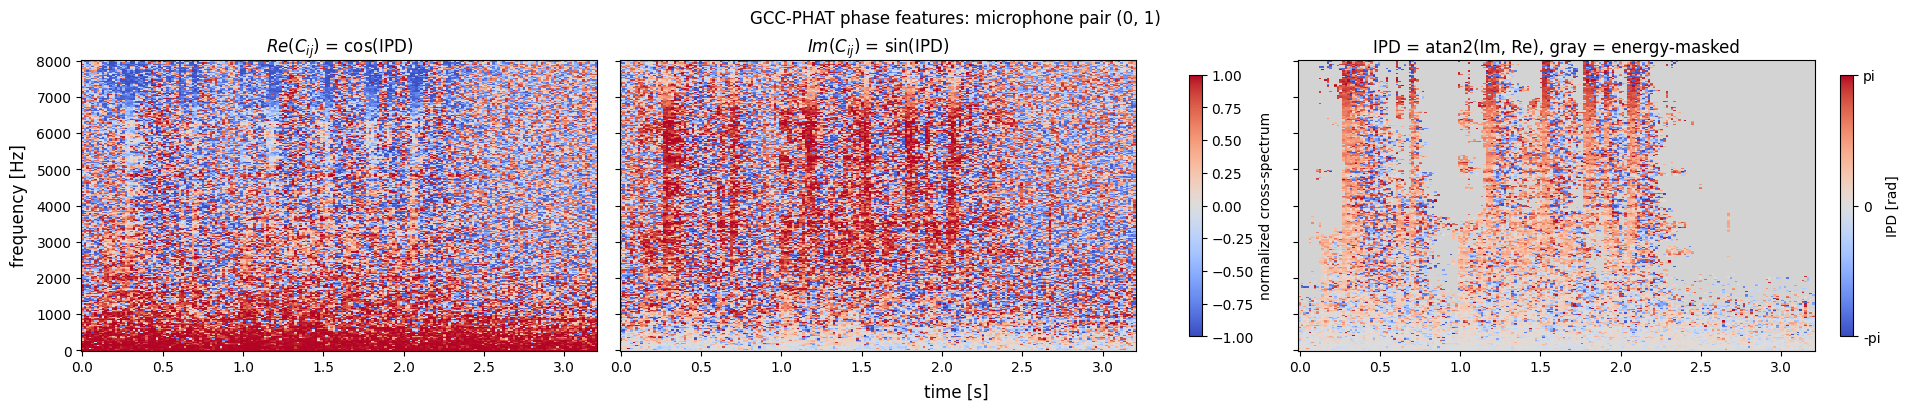

In [14]:
# 앞 셀의 복소 STFT로 모든 마이크 쌍의 5채널 acoustic feature를 계산한다.
coherence_frames = 9
pair_features, mic_pairs = feature_processor.extract_pair_features(
    real,
    imag,
    coherence_frames=coherence_frames,
)

# feature 축: [log|X_i|, log|X_j|, coherence, Re(C_ij), Im(C_ij)]
log_mag_i = pair_features[:, :, 0]
log_mag_j = pair_features[:, :, 1]
coherence = pair_features[:, :, 2]
gcc_real = pair_features[:, :, 3]
gcc_imag = pair_features[:, :, 4]
ipd = torch.atan2(gcc_imag, gcc_real)

assert pair_features.shape[1] == len(mic_pairs)
assert pair_features.shape[2] == 5
assert torch.isfinite(pair_features).all()
assert coherence.amin() >= 0 and coherence.amax() <= 1

print(f"microphone pairs: {len(mic_pairs)} (first five: {mic_pairs[:5]})")
print(f"pair feature shape: {tuple(pair_features.shape)} (B, pair, 5, F, T)")
print(f"coherence range: [{coherence.amin().item():.6f}, {coherence.amax().item():.6f}]")
print(f"IPD shape: {tuple(ipd.shape)} (B, pair, F, T)")

# 에너지가 충분한 TF bin에서 PHAT 정규화 결과의 크기가 거의 1인지 확인한다.
stft_complex = torch.complex(real, imag)
pair_i, pair_j = map(list, zip(*mic_pairs))
raw_cross_magnitude = (stft_complex[:, pair_i] * stft_complex[:, pair_j].conj()).abs()
stable_bins = raw_cross_magnitude > 100 * feature_processor.eps
phat_magnitude = torch.sqrt(gcc_real.square() + gcc_imag.square())
print(f"mean PHAT magnitude (stable bins): {phat_magnitude[stable_bins].mean().item():.6f}")

# 첫 번째 마이크 쌍의 5개 입력 특징과 해석용 IPD를 시각화한다.
pair_no = 0
pair_feature_np = pair_features[0, pair_no].detach().cpu().numpy()
pair_ipd = ipd[0, pair_no].masked_fill(~stable_bins[0, pair_no], torch.nan)
pair_ipd_np = pair_ipd.detach().cpu().numpy()
ipd_cmap = plt.colormaps["coolwarm"].copy()
ipd_cmap.set_bad(color="lightgray")

fig, axes = plt.subplots(2, 3, figsize=(19, 9), sharex=True, sharey=True, constrained_layout=True)
axes = axes.ravel()
feature_panels = [
    (pair_feature_np[0], "log|X_i|", "magma", None, None, "log magnitude"),
    (pair_feature_np[1], "log|X_j|", "magma", None, None, "log magnitude"),
    (pair_feature_np[2], "coherence", "viridis", 0, 1, "coherence"),
    (pair_feature_np[3], "Re(C_ij) = cos(IPD)", "coolwarm", -1, 1, "normalized cross-spectrum"),
    (pair_feature_np[4], "Im(C_ij) = sin(IPD)", "coolwarm", -1, 1, "normalized cross-spectrum"),
]

for ax, (values, title, cmap, value_min, value_max, colorbar_label) in zip(axes[:5], feature_panels):
    image = ax.pcolormesh(
        time_axis,
        freq_axis,
        values,
        shading="auto",
        cmap=cmap,
        vmin=value_min,
        vmax=value_max,
    )
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label=colorbar_label, shrink=0.9)

ipd_image = axes[5].pcolormesh(
    time_axis,
    freq_axis,
    pair_ipd_np,
    shading="auto",
    cmap=ipd_cmap,
    vmin=-np.pi,
    vmax=np.pi,
)
axes[5].set_title("IPD = atan2(Im, Re), gray = energy-masked")
ipd_colorbar = fig.colorbar(ipd_image, ax=axes[5], label="IPD [rad]", shrink=0.9)
ipd_colorbar.set_ticks([-np.pi, 0, np.pi])
ipd_colorbar.set_ticklabels(["-pi", "0", "pi"])

fig.suptitle(f"Pair acoustic features: microphone pair {mic_pairs[pair_no]}")
fig.supxlabel("time [s]")
fig.supylabel("frequency [Hz]")
plt.show()

## 6. 마이크 배열 기하학 표현


### 6.1 좌표 중심화

배열의 절대 위치에 대한 의존성을 제거하기 위해 마이크 좌표를 배열 중심 기준으로 변환한다.

$$
\mathbf r_c
=
\frac{1}{M}
\sum_{m=1}^{M}
\mathbf r_m
$$

$$
\tilde{\mathbf r}_m
=
\mathbf r_m-\mathbf r_c
$$

이 처리를 통해 배열 전체가 공간상에서 평행 이동해도 동일한 상대 기하학을 갖게 된다.

---

In [ ]:
from geometry_feature_process import *


# sample의 (M, 3) 마이크 좌표를 앞선 셀들과 동일하게 배치 축을 추가해 사용한다.
mic_coordinate = torch.as_tensor(sample["mic_coordinate"], dtype=torch.float32).unsqueeze(0)  # (1, M, 3)
centered_mic_coordinate, array_center = center_mic_coordinates(mic_coordinate)

print(f"mic_coordinate shape: {tuple(mic_coordinate.shape)}")
print(f"array center r_c: {array_center.squeeze().tolist()}")
print(f"centered coordinate mean (should be ~0): {centered_mic_coordinate.mean(dim=-2).squeeze().tolist()}")

# LOCATA 데이터는 이미 배열 중심 기준으로 저장되어 있으므로 중심화 전후 좌표가 거의 동일해야 한다.
assert torch.allclose(mic_coordinate, centered_mic_coordinate, atol=1e-5)
assert torch.allclose(centered_mic_coordinate.mean(dim=-2), torch.zeros_like(array_center.squeeze(-2)), atol=1e-6)

### 6.2 마이크 쌍 기하학 특징

마이크 쌍 $(i,j)$의 baseline vector를 다음과 같이 정의한다.

$$
\mathbf d_{ij}
=
\tilde{\mathbf r}_i-\tilde{\mathbf r}_j
$$

baseline 길이는 다음과 같다.

$$
l_{ij}
=
\|\mathbf d_{ij}\|_2
$$

단위 baseline 방향은 다음과 같다.

$$
\bar{\mathbf d}_{ij}
=
\frac{\mathbf d_{ij}}
{l_{ij}+\epsilon}
$$

최대 물리적 시간지연은 다음과 같이 계산할 수 있다.

$$
\tau_{ij}^{\max}
=
\frac{l_{ij}}{c}
$$

여기서 $c$는 음속이다.

최종 geometry feature는 다음과 같이 구성한다.

$$
\mathbf g_{ij}
=
\left[
\mathbf d_{ij},
\bar{\mathbf d}_{ij},
l_{ij},
\tau_{ij}^{\max}
\right]
$$

배열의 실제 크기는 DOA에 따른 위상차에 직접적인 영향을 주므로 좌표를 단순히 단위 크기로 정규화하지 않는다. 대신 중심화된 실제 좌표와 배열 aperture 정보를 함께 입력한다.

$$
D_{\mathrm{array}}
=
\max_{i,j}
\|\mathbf r_i-\mathbf r_j\|_2
$$

---

In [ ]:
pair_geometry, array_aperture = pair_geometry_features(centered_mic_coordinate, mic_pairs)

d_ij = pair_geometry[..., 0:3]
d_ij_unit = pair_geometry[..., 3:6]
l_ij = pair_geometry[..., 6]
tau_ij_max = pair_geometry[..., 7]

print(f"pair_geometry shape: {tuple(pair_geometry.shape)} (B, pair, 8)")
print(f"array aperture D_array: {array_aperture.item():.4f} m")
print(f"baseline length range: [{l_ij.min().item() * 100:.2f}, {l_ij.max().item() * 100:.2f}] cm")
print(f"max physical delay range: [{tau_ij_max.min().item() * 1e6:.1f}, {tau_ij_max.max().item() * 1e6:.1f}] us")

# bar_d_ij는 단위벡터여야 하고, l_ij는 항상 0 이상이어야 한다.
assert torch.allclose(torch.linalg.norm(d_ij_unit, dim=-1), torch.ones_like(l_ij), atol=1e-4)
assert (l_ij >= 0).all()
assert pair_geometry.shape[-2] == len(mic_pairs)
# 완전그래프의 최대 baseline 길이는 곧 배열 aperture와 같아야 한다.
assert torch.isclose(l_ij.amax(), array_aperture, atol=1e-4)

## 7. Geometry-Aware Pair Encoder

각 마이크 쌍에 대해 음향 특징과 기하학 특징을 결합한다.

$$
\mathbf z_{ij}(f,t)
=
\left[
\mathbf a_{ij}(f,t),
\mathbf g_{ij},
\frac{f}{F}
\right]
$$

모든 마이크 쌍에는 동일한 파라미터를 가진 shared encoder를 적용한다.

$$
\mathbf h_{ij}(f,t)
=
E_{\mathrm{pair}}
\left(
\mathbf z_{ij}(f,t)
\right)
$$

shared encoder를 사용하면 마이크 개수와 마이크 쌍의 수가 달라져도 동일한 모델을 적용할 수 있다.

Pair encoder는 다음 구조로 구현할 수 있다.

```text
Pair feature
    │
Linear projection
    │
Frequency convolution or frequency attention
    │
Temporal convolution / conformer block
    │
Geometry-conditioned feature modulation
    │
Pair embedding
```

기하학 특징을 단순 concatenate하는 것 외에도 FiLM 방식으로 음향 특징을 조절할 수 있다.

$$
\boldsymbol\gamma_{ij},
\boldsymbol\beta_{ij}
=
\operatorname{MLP}_{\mathrm{geo}}(\mathbf g_{ij})
$$

$$
\tilde{\mathbf h}_{ij}
=
\boldsymbol\gamma_{ij}
\odot
\mathbf h_{ij}
+
\boldsymbol\beta_{ij}
$$

이 구조는 동일한 위상 패턴이라도 마이크 간 거리와 방향에 따라 다르게 해석하도록 한다.

---


## 8. 마이크 집합 및 그래프 인코더

마이크는 node, 마이크 쌍은 edge인 완전 그래프로 표현한다.

$$
\mathcal G
=
(\mathcal V,\mathcal E)
$$

$$
\mathcal V
=
\{1,\ldots,M\}
$$

$$
\mathcal E
=
\{(i,j)\mid i\neq j\}
$$

각 edge는 pair embedding $\mathbf h_{ij}$를 가진다.

마이크 순서 변화에 영향을 받지 않도록 permutation-invariant attention aggregation을 수행한다.

$$
\mathbf h_i
=
\sum_{j\neq i}
\alpha_{ij}
\mathbf W_v\mathbf h_{ij}
$$

$$
\alpha_{ij}
=
\operatorname{softmax}_j
\left(
\frac{
(\mathbf W_q\mathbf q_i)^\top
(\mathbf W_k\mathbf h_{ij})
}{
\sqrt d
}
\right)
$$

이후 모든 마이크 node를 다시 집합 형태로 통합한다.

$$
\mathbf H
=
E_{\mathrm{set}}
\left(
\{\mathbf h_i\}_{i=1}^{M}
\right)
$$

실제 구현에서는 다음 중 하나를 사용할 수 있다.

- Set Transformer
- Graph Attention Network
- Perceiver-style latent encoder
- SE(3)-equivariant graph neural network

초기 구현에서는 Set Transformer 또는 Graph Attention Network를 사용하는 것이 현실적이며, 후속 실험에서 SE(3)-equivariant 구조를 적용한다.

---

## 9. Multi-Source Set Prediction Decoder


### 9.1 Source query

최대 음원 수 $K_{\max}$만큼 학습 가능한 source query를 정의한다.

$$
\mathbf Q
=
\{\mathbf q_k\}_{k=1}^{K_{\max}}
$$

각 query는 encoder의 전체 시공간 표현 $\mathbf H$에 cross-attention을 수행한다.

$$
\mathbf z_k
=
D_{\mathrm{query}}
(\mathbf q_k,\mathbf H)
$$

각 query는 하나의 잠재적인 음원을 나타내며, 실제 음원 수가 $K_{\max}$보다 적은 경우 나머지 query는 비활성 상태를 출력한다.

---

### 9.2 Activity head

각 source query의 활성 확률을 예측한다.

$$
\hat p_k
=
\sigma
\left(
\operatorname{MLP}_{\mathrm{act}}
(\mathbf z_k)
\right)
$$

추론 단계에서는 다음 조건을 만족하면 활성 음원으로 판단한다.

$$
\hat p_k>\delta
$$

여기서 $\delta$는 activity threshold이다.

---

### 9.3 Direction head

방향 예측 head는 3차원 벡터를 출력한다.

$$
\mathbf v_k
=
\operatorname{MLP}_{\mathrm{dir}}
(\mathbf z_k)
$$

$$
\hat{\mathbf u}_k
=
\frac{\mathbf v_k}
{\|\mathbf v_k\|_2+\epsilon}
$$

이 방식은 고정 방향 grid를 사용하지 않기 때문에 이론적으로 임의의 방향 해상도를 가질 수 있다.

---

### 9.4 최종 source slot

불확실도 head는 사용하지 않는다. 각 source query는 활성 확률과 연속적인 3차원 방향 단위벡터만 출력한다.

$$
\hat s_k
=
(\hat p_k,\hat{\mathbf u}_k)
$$

실제 음원 수가 가변이므로 추론 시 $\hat p_k>\delta$인 query만 활성 음원으로 선택한다. TF responsibility는 기본 set prediction에는 필요하지 않으며, 선택적인 physics-guided 학습 단계에서만 추가한다.

---

## 10. Time-Frequency Source Responsibility

이 head는 기본 set prediction에는 포함하지 않고 optional physics stage에서만 활성화한다. 다중 음원 환경에서는 하나의 시간-주파수 bin에 특정 음원의 에너지가 더 강하게 나타나는 경우가 많으므로, 각 source query가 TF bin별 책임도 또는 soft mask를 예측하도록 한다.

$$
q_k(f,t)
=
\operatorname{softmax}_k
\left(
\mathbf z_k^\top
\mathbf h(f,t)
\right)
$$

배경 또는 diffuse noise를 표현하기 위해 background slot $q_0(f,t)$를 추가할 수 있다.

$$
\sum_{k=0}^{K_{\max}}
q_k(f,t)
=
1
$$

TF responsibility는 반드시 완전한 음원분리 mask일 필요는 없으며, 각 방향을 지지하는 공간적 관측을 구분하는 latent assignment로 사용한다.

---

## 11. Optional Physics-Guided Spatial Decoder

이 모듈과 $\mathcal L_{\mathrm{phys}}$는 필수 학습 구성요소가 아니다. 먼저 Hungarian matching, cosine direction loss, activity BCE만으로 baseline을 학습하고, 이후 배열 일반화에 도움이 되는지 ablation으로 검증한다.


### 11.1 Plane-wave steering vector

원거리 음원과 자유음장 근사를 적용하면 방향 $\mathbf u_k$에서 입사하는 평면파의 steering vector는 다음과 같다.

$$
\mathbf a_f(\mathbf u_k)
=
\begin{bmatrix}
e^{-j\omega_f
\tilde{\mathbf r}_1^\top\mathbf u_k/c}\\
\vdots\\
e^{-j\omega_f
\tilde{\mathbf r}_M^\top\mathbf u_k/c}
\end{bmatrix}
$$

여기서

$$
\omega_f=2\pi f
$$

이다.

마이크 쌍 $(i,j)$에서 예측되는 이론적 위상차는 다음과 같다.

$$
\Delta\hat\phi_{ij,k}(f)
=
-\frac{\omega_f}{c}
\mathbf d_{ij}^\top
\hat{\mathbf u}_k
$$

---

### 11.2 관측 공간 공분산

단일 STFT frame의 outer product는 변동성이 크므로 인접 프레임을 이용해 local spatial covariance matrix를 계산한다.

$$
\mathbf R_{\mathrm{obs}}(f,t)
=
\frac{
\sum_{\tau\in\mathcal W_t}
w_\tau
\mathbf x(f,\tau)
\mathbf x^H(f,\tau)
}{
\sum_{\tau\in\mathcal W_t}w_\tau+\epsilon
}
$$

여기서

$$
\mathbf x(f,t)
=
[X_1(f,t),\ldots,X_M(f,t)]^\top
$$

이다.

---

In [ ]:
import torch
import torch.nn.functional as nnf


def estimate_local_covariance(X, window_frames=9):
    """STFT로부터 local spatial covariance를 계산한다.

    Args:
        X: complex STFT, shape (B, M, F, T)
        window_frames: 시간축 이동평균 길이. 중심 정렬을 위해 홀수를 사용한다.

    Returns:
        R_obs: shape (B, F, T, M, M), complex Hermitian matrix
    """
    if X.ndim != 4 or not torch.is_complex(X):
        raise ValueError("X must be a complex tensor with shape (B, M, F, T)")
    if window_frames <= 0 or window_frames % 2 == 0:
        raise ValueError("window_frames must be a positive odd integer")

    batch, n_mics, n_freq, n_frames = X.shape

    # 각 TF bin의 instantaneous outer product: x(f,t) x(f,t)^H
    instant_cov = torch.einsum("bmft,bnft->bftmn", X, X.conj())

    # avg_pool1d는 complex tensor를 직접 처리하지 않으므로 실수부와 허수부를 따로 평균한다.
    flat_cov = instant_cov.permute(0, 1, 3, 4, 2).reshape(-1, 1, n_frames)
    pool_kwargs = dict(
        kernel_size=window_frames,
        stride=1,
        padding=window_frames // 2,
        count_include_pad=False,
    )
    local_real = nnf.avg_pool1d(flat_cov.real, **pool_kwargs)
    local_imag = nnf.avg_pool1d(flat_cov.imag, **pool_kwargs)
    local_cov = torch.complex(local_real, local_imag)

    return local_cov.reshape(batch, n_freq, n_mics, n_mics, n_frames).permute(0, 1, 4, 2, 3).contiguous()


# 앞 셀의 X는 (M, F, T)이므로 batch 축을 추가한다.
R_obs = estimate_local_covariance(X.unsqueeze(0), window_frames=9)
print(f"observed covariance shape: {tuple(R_obs.shape)} (B, F, T, M, M)")

# 수치 오차 범위에서 Hermitian인지 확인한다.
assert torch.allclose(R_obs, R_obs.mH, atol=1e-5, rtol=1e-4)


### 11.3 예측 공간 공분산

각 음원 방향과 TF responsibility를 이용해 예측 공분산을 구성한다.

$$
\hat{\mathbf R}(f,t)
=
\sum_{k=1}^{K_{\max}}
\gamma_k(f,t)
\mathbf a_f(\hat{\mathbf u}_k)
\mathbf a_f^H(\hat{\mathbf u}_k)
+
\gamma_0(f,t)\mathbf\Gamma_{\mathrm{diff}}(f)
+
\sigma^2(f,t)\mathbf I
$$

여기서

$$
\gamma_k(f,t)
=
\hat p_k
q_k(f,t)
\rho(f,t)
$$

이며, $\rho(f,t)$는 관측 신호 에너지 또는 별도의 network head가 예측한 source power이다.

$\mathbf\Gamma_{\mathrm{diff}}$는 diffuse noise 또는 잔향 성분을 근사하는 공간 공분산이고, $\sigma^2\mathbf I$는 비상관 센서 잡음을 나타낸다.

---

### 11.4 정규화된 공분산 비교

음원 크기보다 공간적 위상 및 상관 구조에 집중하기 위해 공분산 행렬을 trace로 정규화한다.

$$
\bar{\mathbf R}_{\mathrm{obs}}
=
\frac{
\mathbf R_{\mathrm{obs}}
}{
\operatorname{tr}
(\mathbf R_{\mathrm{obs}})
+\epsilon
}
$$

$$
\bar{\mathbf R}_{\mathrm{pred}}
=
\frac{
\hat{\mathbf R}
}{
\operatorname{tr}
(\hat{\mathbf R})
+\epsilon
}
$$

선택적으로 사용하는 physics reconstruction loss는 다음과 같다.

$$
\mathcal L_{\mathrm{phys}}
=
\frac{1}{FT}
\sum_{f,t}
w(f,t)
\left\|
\bar{\mathbf R}_{\mathrm{obs}}(f,t)
-
\bar{\mathbf R}_{\mathrm{pred}}(f,t)
\right\|_F^2
$$

$w(f,t)$는 direct-path dominance, coherence 또는 신호 에너지를 기반으로 정할 수 있다.

잔향이 강하거나 신뢰도가 낮은 TF bin에서는 물리 손실의 비중을 줄인다.

---

## 12. Permutation-Invariant Set Matching

다중 음원의 정답 순서는 정의되지 않는다. 예를 들어 정답 방향이 $\{\mathbf u_1,\mathbf u_2\}$인 경우 모델의 첫 번째 query가 $\mathbf u_2$를 출력하고 두 번째 query가 $\mathbf u_1$을 출력해도 동일한 결과로 평가해야 한다.

이를 위해 Hungarian matching을 적용한다.

예측 source $k$와 정답 source $j$ 사이의 matching cost를 다음과 같이 정의한다.

$$
C_{k,j}
=
\lambda_{\mathrm{dir}}
\left(1-\hat{\mathbf u}_k^\top\mathbf u_j\right)
+
\lambda_{\mathrm{act}}
\left(-\log\hat p_k\right)
$$

matching과 학습에는 수치적으로 안정적인 cosine distance를 사용한다. 실제 각도 오차는 평가 단계에서 다음과 같이 계산한다.

$$
d_{\mathrm{ang}}
(\hat{\mathbf u},\mathbf u)
=
\arccos
\left(
\operatorname{clip}
(\hat{\mathbf u}^\top\mathbf u,-1,1)
\right)
$$

최적 matching은 다음과 같이 구한다.

$$
\hat\pi
=
\arg\min_{\pi}
\sum_{j=1}^{K}
C_{\pi(j),j}
$$

matching되지 않은 source query는 inactive target으로 학습한다.

---

## 13. 손실함수

불확실도는 예측하지 않고 좌표계 회전은 data augmentation으로 처리한다. 따라서 기본 학습은 다중 음원 set prediction에 필요한 두 항만 사용한다.

$$
\mathcal L_{\mathrm{total}}
=
\mathcal L_{\mathrm{dir}}
+
\beta_{\mathrm{act}}
\mathcal L_{\mathrm{act}}
$$

---

### 13.1 Set prediction loss

$$
\mathcal L_{\mathrm{set}}
=
\mathcal L_{\mathrm{dir}}
+
\beta_{\mathrm{act}}
\mathcal L_{\mathrm{act}}
$$

Hungarian matching으로 대응된 활성 query에만 cosine direction loss를 적용한다.

$$
\mathcal L_{\mathrm{dir}}
=
\frac{1}{\max(1,K)}
\sum_{j=1}^{K}
\left(
1-
\hat{\mathbf u}_{\hat\pi(j)}^\top
\mathbf u_j
\right)
$$

방향 벡터의 내적은 cosine similarity이므로 정답과 같은 방향이면 loss가 0이다. $K=0$인 무음 sample에서는 방향 loss를 0으로 둔다. $\arccos$는 경계 부근의 gradient가 불안정할 수 있어 학습 loss에는 넣지 않고 평가 지표를 계산할 때만 사용한다.

---

### 13.2 Activity loss

Hungarian matching된 query 집합을 $\mathcal M$, matching되지 않은 query 집합을 $\mathcal U$라고 한다. 활성 query에는 target 1, 비활성 query에는 target 0을 부여한다.

$$
\mathcal L_{\mathrm{act}}
=
-\frac{1}{\max(1,|\mathcal M|)}
\sum_{k\in\mathcal M}
\log\hat p_k
-
\lambda_{\mathrm{noobj}}
\frac{1}{\max(1,|\mathcal U|)}
\sum_{k\in\mathcal U}
\log(1-\hat p_k)
$$

비활성 query 수가 활성 음원 수보다 많을 수 있으므로 $\lambda_{\mathrm{noobj}}$로 비활성 항의 영향을 낮춘다. 초기값으로 $\beta_{\mathrm{act}}=0.5$, $\lambda_{\mathrm{noobj}}=0.2$를 사용하고 validation set에서 조정한다.

---

### 13.3 Rotation data augmentation

좌표계 회전행렬 $\mathbf Q\in SO(3)$를 생성한다.

마이크 좌표와 정답 방향에 동일한 회전을 적용한다.

$$
\mathbf r'_m
=
\mathbf Q\mathbf r_m
$$

$$
\mathbf u'_j
=
\mathbf Q\mathbf u_j
$$

오디오 신호는 유지하고 좌표 표현과 정답 방향을 함께 회전시킨 sample을 학습 데이터로 사용한다. 이는 동일한 물리 장면을 회전된 좌표계로 다시 표현하는 augmentation이다.

회전된 sample에도 동일한 $\mathcal L_{\mathrm{dir}}+\beta_{\mathrm{act}}\mathcal L_{\mathrm{act}}$를 적용한다. 별도의 rotation consistency loss는 사용하지 않는다.

---

### 13.4 Microphone and geometry augmentation

마이크 개수 변화와 센서 손실에 대한 강건성은 별도의 consistency loss 대신 입력 augmentation으로 학습한다. 전체 마이크 집합에서 일부 채널을 무작위로 제거하고 오디오 채널과 좌표를 동일한 인덱스로 선택한다.

$$
\mathcal M'
\subset
\{1,\ldots,M\}
$$

마이크 위치 오차는 $\mathbf r'_m=\mathbf r_m+\boldsymbol\epsilon_m$ 형태로 추가한다. 채널 제거 후 배열이 3차원 방향을 물리적으로 구분할 수 없는 경우가 있으므로 원본 배열과 부분 배열의 출력을 강제로 같게 만드는 subset consistency loss는 사용하지 않는다.

---

### 13.5 Optional physics loss

공분산 physics loss는 기본 set prediction이 수렴한 뒤 배열 일반화 효과를 검증하기 위한 선택 항목으로만 추가한다.

$$
\mathcal L_{\mathrm{total}}
=
\mathcal L_{\mathrm{set}}
+
\lambda_{\mathrm{phys}}
\mathcal L_{\mathrm{phys}}
$$

초기 실험에서는 $\lambda_{\mathrm{phys}}=0$으로 두고, baseline이 안정적으로 학습된 뒤 warm-up을 거쳐 작은 값부터 증가시킨다. 별도의 source count loss는 사용하지 않으며 추론 시 activity threshold를 통과한 query 수를 예측 음원 수로 사용한다.

---

## 14. 3차원 배열 관측 가능성

모든 배열이 동일한 수준의 3차원 정보를 제공하는 것은 아니다.

마이크 baseline으로 geometry matrix를 구성한다.

$$
\mathbf G
=
\sum_{i<j}
w_{ij}
\mathbf d_{ij}
\mathbf d_{ij}^\top
$$

3차원 관측 가능성 지표를 다음과 같이 정의한다.

$$
o_{\mathrm{3D}}
=
\frac{
\lambda_{\min}(\mathbf G)
}{
\operatorname{tr}(\mathbf G)+\epsilon
}
$$

모든 마이크가 하나의 평면에 위치하면 최소 고유값이 0에 가까워지므로 $o_{\mathrm{3D}}$가 작아진다.

이 경우 평면 위쪽과 아래쪽 방향이 유사한 TDOA를 생성할 수 있어 고도각 부호가 모호해질 수 있다.

따라서 $o_{\mathrm{3D}}$를 geometry token에 추가한다.

$$
\mathbf g_{\mathrm{global}}
=
[
D_{\mathrm{array}},
o_{\mathrm{3D}},
\operatorname{cond}(\mathbf G),
M
]
$$

$\mathbf g_{\mathrm{global}}$은 set encoder의 geometry token으로 사용할 수 있다. 또한 배열 종류별 성능을 해석하는 분석 지표로 사용하되, 별도의 uncertainty head나 loss는 두지 않는다.

---

## 15. 학습 전략


### Stage 1. 단일 음원 기초 학습

- 단일 음원
- 높은 SNR
- 낮은 잔향
- 비공면 마이크 배열
- cosine direction loss 중심 학습

목적은 마이크 위치, 위상차 및 방향 사이의 기본 물리 관계를 학습하는 것이다.

---

### Stage 2. 배열 일반화 학습

- 마이크 개수 무작위화
- 마이크 순서 무작위 permutation
- linear, circular, planar, spherical, random 배열
- 배열 aperture 무작위화
- 마이크 좌표 오차 추가
- channel dropout 적용
- 마이크 좌표와 정답 방향에 동일한 random rotation augmentation 적용
- 별도의 rotation consistency loss는 사용하지 않음

마이크 위치 오차는 다음과 같이 생성한다.

$$
\mathbf r_m'
=
\mathbf r_m+\boldsymbol\epsilon_m
$$

$$
\boldsymbol\epsilon_m
\sim
\mathcal N
(\mathbf 0,\sigma_r^2\mathbf I)
$$

---

### Stage 3. 다중 음원 학습

- 동시 음원 수 1–4개
- 음원 간 최소 각도 점진적 감소
- 부분 중첩 및 완전 중첩
- 동일 화자 및 서로 다른 음향 이벤트
- Hungarian matching 적용
- 기본 loss는 Hungarian matching + cosine direction loss + activity BCE
- source responsibility head는 optional physics stage에서만 활성화

초기에는 음원 간 각도를 크게 설정하고 학습 후반에 가까운 음원 조건을 증가시킨다.

---

### Stage 4. Optional physics-guided 학습

Stage 3의 supervised set prediction baseline이 수렴한 뒤에만 physics loss를 선택적으로 추가한다. 처음부터 physics loss를 크게 적용하면 잔향과 noise 때문에 최적화가 불안정해질 수 있다.

따라서 다음과 같은 weight scheduling을 사용한다.

$$
\lambda_{\mathrm{phys}}(e)
=
\lambda_{\max}
\min
\left(
1,
\frac{e}{E_{\mathrm{warmup}}}
\right)
$$

여기서 $e$는 epoch이고, $E_{\mathrm{warmup}}$은 physics loss warm-up epoch이다.

---

### Stage 5. Sim-to-Real 적응

- 실제 RIR 사용
- microphone gain mismatch
- microphone phase mismatch
- diffuse noise
- 센서 고장
- 실제 녹음 데이터 fine-tuning
- label이 부족한 경우 optional physics loss 활용

---

## 16. 추론 과정

추론 단계는 다음과 같다.

```text
Input:
    Multichannel audio X
    Microphone coordinates R

1. Perform STFT.
2. Construct all microphone-pair spatial features.
3. Encode pairwise acoustic and geometric information.
4. Aggregate variable-size microphone representations.
5. Decode K_max source queries.
6. Estimate activity probability and continuous 3D direction.
7. Remove slots whose activity probability is below threshold.
8. Optionally merge duplicated directions using angular NMS.
9. Convert Cartesian unit vectors to azimuth and elevation.
```

중복 방향을 제거하기 위해 angular non-maximum suppression을 사용할 수 있다.

두 예측 방향 사이의 각도가 임계값 이하이면 낮은 activity score를 가진 예측을 제거한다.

$$
d_{\mathrm{ang}}
(\hat{\mathbf u}_i,\hat{\mathbf u}_j)
<
\delta_{\mathrm{merge}}
$$

---

## 17. 학습 알고리즘

```python
for audio, mic_positions, gt_directions in dataloader:

    # 좌표계 회전 augmentation: audio는 유지하고 좌표와 정답 방향만 함께 회전
    mic_positions, gt_directions = random_rotate_coordinates(
        mic_positions,
        gt_directions,
    )

    # 1. STFT
    X = stft(audio)

    # 2. Pairwise acoustic features
    pair_features = extract_pair_features(X)

    # 3. Relative microphone geometry
    geometry_features = build_geometry_features(mic_positions)

    # 4. Geometry-aware pair encoding
    pair_embeddings = pair_encoder(
        pair_features,
        geometry_features
    )

    # 5. Variable-size microphone set encoding
    scene_embedding = set_graph_encoder(
        pair_embeddings,
        mic_positions
    )

    # 6. Multi-source query decoding
    activity, doa_vector = query_decoder(
        scene_embedding
    )

    # 7. Hungarian matching
    matching = hungarian_match(
        activity,
        doa_vector,
        gt_directions
    )

    # 8. Minimal supervised set loss
    loss_dir = matched_cosine_loss(
        doa_vector,
        gt_directions,
        matching,
    )

    loss_act = matched_activity_bce(
        activity,
        matching,
        no_object_weight=0.2,
    )

    loss = loss_dir + 0.5 * loss_act

    # 9. Optional physics stage: baseline 수렴 후에만 활성화
    if use_physics:
        tf_responsibility = responsibility_head(scene_embedding)
        steering_vectors = build_steering_vectors(doa_vector, mic_positions)
        predicted_covariance = reconstruct_covariance(
            steering_vectors,
            tf_responsibility,
            activity,
        )
        observed_covariance = estimate_local_covariance(X)
        loss_phys = covariance_loss(predicted_covariance, observed_covariance)
        loss = loss + lambda_phys * loss_phys

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
```

---

## 18. 예상 연구 기여점

본 연구의 기여점은 다음과 같이 정리할 수 있다.

### Contribution 1. 배열 비종속 다중 음원 3D DOA 추정

고정된 마이크 개수나 특정 배열 형태를 가정하지 않고, 마이크 좌표와 pairwise spatial feature를 이용하여 다양한 배열에 하나의 모델을 적용한다.

### Contribution 2. Grid-free set prediction

방향 grid 분류 대신 다중 음원의 DOA를 연속적인 3차원 단위벡터 집합으로 직접 추정한다. 이를 통해 방향 해상도가 사전 정의된 grid 간격에 제한되지 않는다.

### Contribution 3. 선택적 다중 음원 물리 디코더

기본 set prediction baseline이 수렴한 뒤, 예측된 복수 음원 방향과 TF responsibility로부터 공간 공분산을 재구성하는 보조 loss를 선택적으로 적용한다. 이를 통해 복잡한 physics loss의 실효성을 baseline과 직접 비교할 수 있다.

### Contribution 4. 배열 변환 augmentation

좌표계 random rotation, 마이크 permutation, channel dropout 및 마이크 위치 오차를 data augmentation으로 적용하여 학습하지 않은 배열에 대한 일반화를 강화한다. 별도의 consistency loss는 사용하지 않는다.

### Contribution 5. 3차원 배열 관측 가능성 분석

마이크 배열의 3차원 관측 가능성을 분석하여 평면 배열이나 작은 aperture에서 발생하는 물리적 모호성을 정량화하고, 배열 종류별 성능 해석에 활용한다.

---

## 19. 핵심 Ablation Study

| 실험 | 제거하거나 변경할 요소 | 확인 목적 |
|---|---|---|
| A1 | Geometry feature 제거 | 마이크 좌표 입력의 효과 |
| A2 | Baseline에 optional physics loss 추가 | 공분산 보조 loss의 추가 효과 |
| A3 | Set decoder를 grid classifier로 교체 | 연속 방향 집합 출력 효과 |
| A4 | Random rotation augmentation 제거 | 좌표계 변화 일반화 효과 |
| A5 | Channel dropout augmentation 제거 | 채널 손실 강건성 |
| A6 | Activity head 제거 또는 고정 음원 수 가정 | 가변 음원 수 추정 효과 |
| A7 | Optional physics stage에서 TF responsibility 제거 | 근접 다중 음원 분리 효과 |
| A8 | 실제 좌표 대신 배열 ID 사용 | geometry generalization 검증 |
| A9 | 공분산 decoder 대신 pairwise phase loss 사용 | 물리 decoder 설계 비교 |
| A10 | 평면 배열과 비공면 배열 비교 | 3D 관측 가능성 검증 |

---

## 20. 연구 범위와 한계

본 방법은 기본적으로 원거리 plane-wave 조건을 가정한다.

따라서 음원이 배열에 매우 가까운 경우에는 거리 정보와 spherical-wave steering vector를 추가해야 한다.

$$
a_{m,f}(\mathbf s)
=
\frac{1}{\|\mathbf s-\mathbf r_m\|}
\exp
\left(
-j\frac{\omega_f}{c}
\|\mathbf s-\mathbf r_m\|
\right)
$$

또한 강한 잔향 환경에서는 단순한 direct-path steering vector만으로 실제 공간 공분산을 완전히 설명할 수 없다.

이를 완화하기 위해 다음 요소가 필요하다.

- diffuse covariance component
- learned residual covariance
- coherence-based TF weighting
- 실제 RIR 기반 fine-tuning
- optional physics loss warm-up

마지막으로 공면 배열에서는 순수한 TDOA 및 위상 정보만으로 상하 대칭 방향을 완전히 구분하지 못할 수 있다. 따라서 모든 배열에서 동일한 수준의 3차원 DOA 성능을 보장한다는 주장은 피해야 한다.

---

## 21. 최종 방법론 요약

PhysSet-DOA는 다채널 음향 신호와 가변적인 마이크 좌표를 입력받아, 마이크 쌍별 위상 특징과 상대 기하학 정보를 학습한다.

마이크 배열은 순서 없는 집합 또는 그래프로 처리되며, 복수의 source query가 활성 확률과 연속적인 3차원 방향벡터를 출력한다.

기본 학습은 Hungarian matching으로 순서 없는 예측과 정답을 대응시킨 뒤 cosine direction loss와 activity BCE만 사용한다. 회전 일반화는 좌표와 정답 방향을 함께 회전하는 data augmentation으로 학습하며, 불확실도, count loss 및 consistency loss는 사용하지 않는다.

Physics-guided spatial covariance reconstruction은 기본 모델이 수렴한 뒤에만 선택적으로 추가한다. 이를 통해 단순한 supervised set prediction baseline과 물리 보조 loss의 효과를 명확히 비교한다.

전체 구조는 다음과 같이 요약할 수 있다.

$$
\boxed{
\text{Pairwise Acoustic Features}
+
\text{Geometry-Aware Set Prediction}
+
\text{Optional Physics Loss}
}
$$